In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import clip
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from tqdm import tqdm
from scipy.linalg import orthogonal_procrustes


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [6]:
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [7]:
train_ds = datasets.STL10(
    root="stl10/",
    split="train",
    download=True,
    transform=preprocess)

test_ds = datasets.STL10(
    root="stl10/",
    split="test",
    download=True,
    transform=preprocess,
    )


In [8]:
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2)

# 3) STL-10 class names (official order)
class_names = [
    "airplane", "bird", "car", "cat", "deer",
    "dog", "horse", "monkey", "ship", "truck"
]

# 4) Prompt strategies
prompt_sets = {
    "plain": [c for c in class_names],
    "photo": [f"a photo of a {c}" for c in class_names],
    "descriptive": [
        f"a photo of a {c}, a type of object from the STL-10 dataset"
        for c in class_names
    ],
}

# 5) Precompute text features for each prompt set
text_features = {}
with torch.no_grad():
    for name, prompts in prompt_sets.items():
        tokens = clip.tokenize(prompts).to(device)
        feats = model.encode_text(tokens)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        text_features[name] = feats

# 6) Evaluate
def accuracy_for_prompt(text_feat):
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            img_feat = model.encode_image(images)
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

            # cosine similarity
            logits = img_feat @ text_feat.T
            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

for name, feats in text_features.items():
    acc = accuracy_for_prompt(feats)
    print(f"{name}: {acc:.4f}")

plain: 0.9624
photo: 0.9738
descriptive: 0.9744


c:\Users\PCF\.conda\envs\sds-venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\PCF\.conda\envs\sds-venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


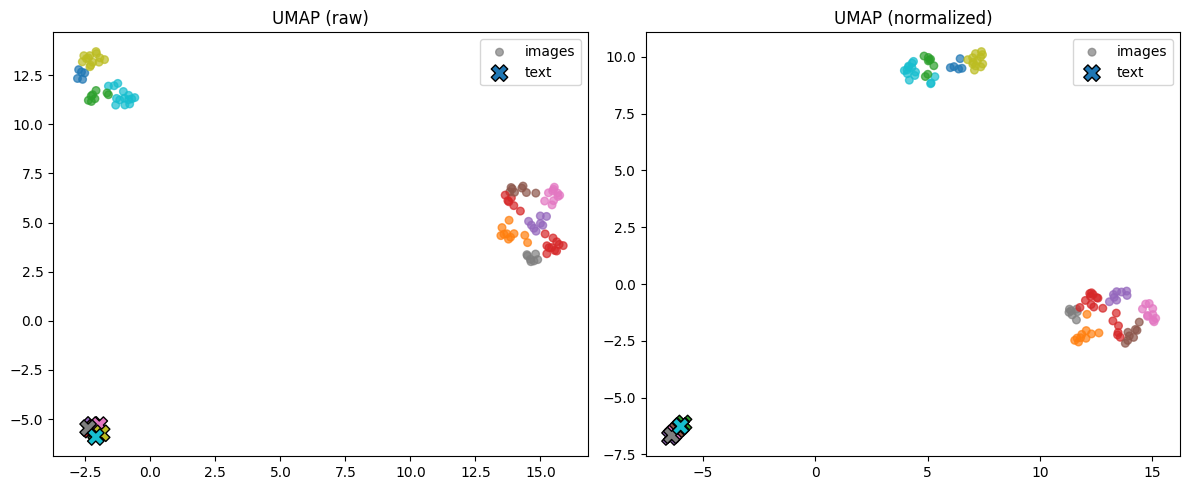

In [9]:
class_names = [
    "airplane", "bird", "car", "cat", "deer",
    "dog", "horse", "monkey", "ship", "truck"
]

# --- load STL-10 test set ---
ds = datasets.STL10(root="stl10", split="test", download=True, transform=preprocess)

N = 100
idxs = random.sample(range(len(ds)), N)
images, labels = zip(*[ds[i] for i in idxs])
images = torch.stack(images).to(device)
labels = torch.tensor(labels).to(device)

# text prompts
prompts = [f"a photo of a {c}" for c in class_names]
text_tokens = clip.tokenize(prompts).to(device)

with torch.no_grad():
    img_feat = model.encode_image(images)
    txt_feat = model.encode_text(text_tokens)

def project_2d(X):
    try:
        import umap
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
        return reducer.fit_transform(X), "UMAP"
    except ImportError:
        
        return TSNE(n_components=2, perplexity=15, init="random", random_state=42).fit_transform(X), "t-SNE"

def run_case(do_norm):
    if do_norm:
        X_img = img_feat / img_feat.norm(dim=-1, keepdim=True)
        X_txt = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
    else:
        X_img, X_txt = img_feat, txt_feat

    X = torch.cat([X_img, X_txt], dim=0).cpu().numpy()
    X2, method = project_2d(X)
    return X2, method

X2_raw, method_raw = run_case(False)
X2_norm, method_norm = run_case(True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, X2, title in [
    (axes[0], X2_raw, f"{method_raw} (raw)"),
    (axes[1], X2_norm, f"{method_norm} (normalized)")
]:
    ax.scatter(X2[:N, 0], X2[:N, 1], c=labels.cpu(), cmap="tab10", s=30, alpha=0.7, label="images")
    ax.scatter(X2[N:, 0], X2[N:, 1], c=range(10), cmap="tab10", s=140, marker="X", edgecolor="k", label="text")
    ax.set_title(title)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

c:\Users\PCF\.conda\envs\sds-venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\PCF\.conda\envs\sds-venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


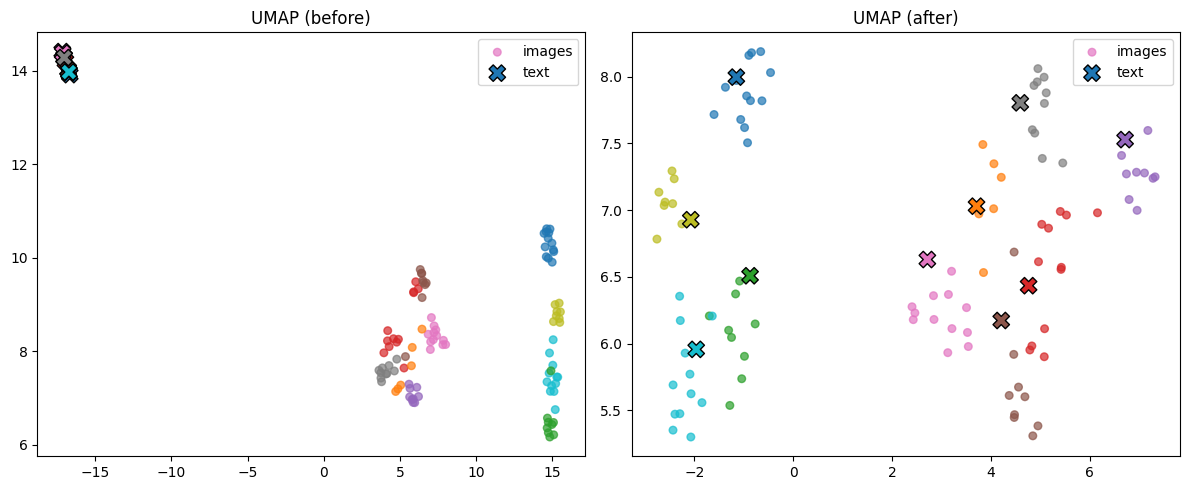

Accuracy before alignment: 0.9738
Accuracy after  alignment: 0.9778


In [12]:
N = 100
idxs = random.sample(range(len(ds)), N)
images, labels = zip(*[ds[i] for i in idxs])
images = torch.stack(images).to(device)
labels = torch.tensor(labels).to(device)

# text prompts (one per class)
prompts = [f"a photo of a {c}" for c in class_names]
text_tokens = clip.tokenize(prompts).to(device)

with torch.no_grad():
    img_feat = model.encode_image(images)
    txt_feat = model.encode_text(text_tokens)

# Optional: choose whether to normalize before alignment
do_norm = True
if do_norm:
    img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
    txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

# --- pair each image with its class text embedding ---
# X = image embeddings, Y = corresponding text embedding for that image's label
X = img_feat.cpu().numpy()
Y = txt_feat[labels].cpu().numpy()  # pick text embedding for each image's label

# --- orthogonal Procrustes: find R so X @ R ≈ Y ---
R, _ = orthogonal_procrustes(X, Y)

# --- apply rotation to all image embeddings ---
X_aligned = X @ R

# --- visualization (UMAP or t-SNE) ---
def project_2d(A):
    try:
        import umap
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
        return reducer.fit_transform(A), "UMAP"
    except ImportError:
        from sklearn.manifold import TSNE
        return TSNE(n_components=2, perplexity=15, init="random", random_state=42).fit_transform(A), "t-SNE"

# stack image + text for before/after plots
X2_before, method = project_2d(np.vstack([X, txt_feat.cpu().numpy()]))
X2_after, _ = project_2d(np.vstack([X_aligned, txt_feat.cpu().numpy()]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, X2, title in [
    (axes[0], X2_before, f"{method} (before)"),
    (axes[1], X2_after, f"{method} (after)"),
]:
    ax.scatter(X2[:N, 0], X2[:N, 1], c=labels.cpu(), cmap="tab10", s=30, alpha=0.7, label="images")
    ax.scatter(X2[N:, 0], X2[N:, 1], c=range(10), cmap="tab10", s=140, marker="X", edgecolor="k", label="text")
    ax.set_title(title)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

# --- accuracy comparison on full test set ---
from torch.utils.data import DataLoader

test_loader = DataLoader(ds, batch_size=128, shuffle=False, num_workers=2)
with torch.no_grad():
    # precompute text features for classifier
    text_feat_full = model.encode_text(text_tokens)
    if do_norm:
        text_feat_full = text_feat_full / text_feat_full.norm(dim=-1, keepdim=True)

def eval_accuracy(use_aligned=False):
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labs in test_loader:
            imgs = imgs.to(device)
            labs = labs.to(device)
            feats = model.encode_image(imgs)
            if do_norm:
                feats = feats / feats.norm(dim=-1, keepdim=True)

            if use_aligned:
                feats = feats.cpu().numpy() @ R
                feats = torch.tensor(feats, device=device, dtype=text_feat_full.dtype)

            logits = feats @ text_feat_full.T
            preds = logits.argmax(dim=1)
            correct += (preds == labs).sum().item()
            total += labs.size(0)
    return correct / total

acc_before = eval_accuracy(use_aligned=False)
acc_after = eval_accuracy(use_aligned=True)
print(f"Accuracy before alignment: {acc_before:.4f}")
print(f"Accuracy after  alignment: {acc_after:.4f}")
